# Milestone 1: Transformer Encoder Implementation

This notebook implements the core building blocks of a Transformer encoder and validates the training pipeline on a small subset of the Fake News Classification dataset.

Dataset:
Fake News Classification (Kaggle)
https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

In [1]:
!git clone https://github.com/Raneem-baymain/Transformer-FakeNews-Classifier.git

Cloning into 'Transformer-FakeNews-Classifier'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 16 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 14.88 KiB | 4.96 MiB/s, done.


In [2]:
import os
os.chdir("Transformer-FakeNews-Classifier/milestone1A")

print("Current directory:", os.getcwd())
print("Files:", os.listdir())

Current directory: /content/Transformer-FakeNews-Classifier/milestone1A
Files: ['Multihead__milestone1t_fixed.ipynb', 'config.py', 'README.md']


In [3]:
import config
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import random
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

## Reproducibility (Seed-Setting)

To guarantee that all reported results are fully reproducible, we fix a single random seed (`SEED = 42`, defined in `config.py`) for **all** sources of randomness before any data loading or model creation:

- **Python** `random`
- **NumPy**
- **PyTorch** (CPU and CUDA)
- **cuDNN** (deterministic kernels, autotuner disabled)

The same seed is also propagated to the train/val/test split (`random_state=SEED`) and to the `DataLoader` shuffling (`generator`). Re-running this notebook top-to-bottom reproduces the reported losses, accuracy, and confusion matrix exactly on the same runtime.

In [4]:
SEED = config.SEED  # 42

def set_seed(seed: int = SEED):
    """Fix all sources of randomness for full reproducibility."""
    random.seed(seed)                          # Python random
    np.random.seed(seed)                       # NumPy
    torch.manual_seed(seed)                    # PyTorch CPU
    torch.cuda.manual_seed_all(seed)           # PyTorch GPU (all devices)
    torch.backends.cudnn.deterministic = True  # deterministic conv kernels
    torch.backends.cudnn.benchmark = False     # disable non-deterministic autotuner

def seeded_generator(seed: int = SEED):
    """Generator for reproducible DataLoader shuffling."""
    g = torch.Generator()
    g.manual_seed(seed)
    return g

set_seed()
print(f"Seed set to {SEED} - results are reproducible.")

Seed set to 42 - results are reproducible.


## A) Transformer Core Implementation

### 1. Scaled Dot-Product Attention

We implement the scaled dot-product attention mechanism as defined in Vaswani et al. (2017):

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^{T}}{\sqrt{d_k}}\right)V$$

In [5]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.d_k = d_k

    def forward(self, Q, K, V, mask=None):
        # Q, K, V = [batch, heads, seq_len, d_k]

        scores = torch.matmul(Q, K.transpose(-2, -1))
        # scores = [batch, heads, seq_len, seq_len]

        scores = scores / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = torch.softmax(scores, dim=-1)
        # attn_weights = [batch, heads, seq_len, seq_len]

        output = torch.matmul(attn_weights, V)
        # output = [batch, heads, seq_len, d_k]

        return output, attn_weights

### 2. Multi-Head Attention (MHA)

The multi-head attention mechanism is defined as:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\,W^{O}$$
$$\text{head}_i = \text{Attention}(QW_i^{Q},\, KW_i^{K},\, VW_i^{V})$$

Multi-head attention splits the input into multiple heads,
applies attention independently, concatenates the outputs,
and projects them back to the model dimension.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

        self.W_O = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(self.d_k)

    def forward(self, x, mask=None):
        # x = [batch, seq_len, d_model]

        batch_size = x.size(0)
        seq_len = x.size(1)

        # Linear projections
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)
        # Q, K, V = [batch, seq_len, d_model]

        # Split heads
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k)
        # [batch, seq_len, heads, d_k]

        # Transpose
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        # [batch, heads, seq_len, d_k]

        # Attention
        attn_output, attn_weights = self.attention(Q, K, V, mask)

        # Transpose back
        attn_output = attn_output.transpose(1, 2)
        # [batch, seq_len, heads, d_k]

        # Concatenate heads
        attn_output = attn_output.contiguous().view(batch_size, seq_len, self.d_model)
        # [batch, seq_len, d_model]

        output = self.W_O(attn_output)
        # [batch, seq_len, d_model]

        return output

### 3. Transformer Encoder Block

The encoder block consists of:
- Multi-Head Attention
- Residual connection + LayerNorm
- Feed Forward Network (FFN)
- Residual connection + LayerNorm
- Dropout

In [7]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # 1. Multi-Head Attention layer
        self.mha = MultiHeadAttention(d_model, num_heads)

        # 2. Feed Forward Network (FFN)
        # Expands to d_ff, applies ReLU, then compresses back to d_model
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        # 3. Normalization & Dropout layers
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Input x shape: [batch_size, seq_len, d_model]

        # Block 1: Self-Attention
        attn_output = self.mha(x, mask)
        # attn_output shape: [batch_size, seq_len, d_model]

        # Block 2: Add & Norm 1 (Residual Connection)
        attn_output = self.dropout(attn_output)
        x = x + attn_output                     # Residual connection (Add)
        x = self.norm1(x)
        # x shape: [batch_size, seq_len, d_model]

        # Block 3: Feed Forward Network
        ffn_output = self.ffn(x)
        # ffn_output shape: [batch_size, seq_len, d_model]

        # Block 4: Add & Norm 2 (Residual Connection)
        ffn_output = self.dropout(ffn_output)
        x = x + ffn_output                      # Residual connection (Add)
        x = self.norm2(x)

        # Final output shape: [batch_size, seq_len, d_model]
        return x

### 4. Positional Embedding

We use learned positional embeddings to encode token position information.

In [8]:
class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        batch_size, seq_len = x.size()
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        return self.pos_embedding(positions)

### 5. Transformer Classifier

We combine embeddings, encoder block, and a final classification head
to perform news classification.

In [9]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_classes, max_seq_len=100, dropout=0.1):
        super().__init__()

        self.d_model = d_model
        # 1. Embedding layers for tokens and their positions
        self.tok_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding_layer = LearnedPositionalEmbedding(max_seq_len, d_model)

        # 2. Main Transformer Encoder unit
        self.encoder_block = TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)

        # 3. Final decision layer (Classification Head)
        self.fc_out = nn.Linear(d_model, num_classes)

        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(d_model) # Scaling factor per original paper

    def forward(self, x, mask=None):
        # Step 1: Compute scaled token and positional embeddings
        token_embeds = self.tok_embedding(x) * self.scale
        pos_embeds = self.pos_embedding_layer(x)

        # Step 2: Combine embeddings and pass through the encoder
        x = self.dropout(token_embeds + pos_embeds)
        x = self.encoder_block(x, mask)

        # Step 3: Pooling - Aggregate all word vectors into one sentence vector
        x = x.mean(dim=1)

        # Step 4: Final classification output
        return self.fc_out(x)

## B) Correctness Checks

We perform simple unit tests to verify the correctness of the implemented attention mechanisms and ensure that the model components behave as expected.

### 1. Shape Check for Q, K, V and Output
We verify that the attention module preserves the expected tensor dimensions.

In [10]:
batch_size = 2
num_heads = 8
seq_len = 5
d_k = 8

Q = torch.rand(batch_size, num_heads, seq_len, d_k)
K = torch.rand(batch_size, num_heads, seq_len, d_k)
V = torch.rand(batch_size, num_heads, seq_len, d_k)

attention = ScaledDotProductAttention(d_k)
output, attn_weights = attention(Q, K, V)

assert output.shape == (batch_size, num_heads, seq_len, d_k)
assert attn_weights.shape == (batch_size, num_heads, seq_len, seq_len)

print("Shape test passed.")

Shape test passed.


### 2. Mask Behavior Sanity Check
We verify that masked positions do not contribute to attention scores.

In [11]:
mask = torch.ones(batch_size, 1, seq_len, seq_len)
mask[:, :, :, -1] = 0  # mask last token

output, attn_weights = attention(Q, K, V, mask=mask)

# masked column should have near-zero attention
assert torch.all(attn_weights[:, :, :, -1] < 1e-6)

print("Mask test passed.")

Mask test passed.


### 3. Attention Weights Sum to One
We verify that attention weights sum to approximately 1 along the last dimension.

In [12]:
output, attn_weights = attention(Q, K, V)

sum_weights = attn_weights.sum(dim=-1)

assert torch.allclose(sum_weights, torch.ones_like(sum_weights), atol=1e-5)

print("Attention sum test passed.")

Attention sum test passed.


### 4. Gradient Flow Check

We run a tiny forward and backward pass to verify that gradients flow properly and loss decreases.
The seed is re-applied so this test itself is reproducible.

In [13]:
set_seed()  # reproducible unit test

model = TransformerClassifier(
    vocab_size=1000,
    d_model=config.D_MODEL,
    num_heads=config.NUM_HEADS,
    d_ff=config.D_FF,
    num_classes=2,
    max_seq_len=config.MAX_SEQ_LEN,
    dropout=config.DROPOUT
)

dummy_input = torch.randint(0, 1000, (8, 20))
dummy_labels = torch.randint(0, 2, (8,))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

losses = []

for _ in range(3):
    optimizer.zero_grad()
    outputs = model(dummy_input)
    loss = criterion(outputs, dummy_labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print("Gradient flow test completed.")

Gradient flow test completed.


## C) Data and Task Design Brief

### Fake News Classification

This study uses the (Fake News Classification) dataset from Kaggle. It is structured for supervised binary classification, where news articles are labeled as fake (0) or real (1). The dataset provides textual content as input features and corresponding labels as the ground truth for training and evaluation.

In [14]:
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")
print("Path:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "WELFake_Dataset.csv"))
print("Shape:", df.shape)
print(df["label"].value_counts())

100%|██████████| 92.1M/92.1M [00:06<00:00, 15.4MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/saurabhshahane/fake-news-classification/versions/77
Files: ['WELFake_Dataset.csv']
Shape: (72134, 4)
label
1    37106
0    35028
Name: count, dtype: int64


### Text Preprocessing

In this stage, the textual data was cleaned and standardized to improve model performance.
Location tags and news source prefixes (e.g., "WASHINGTON (Reuters) -") were removed from the beginning of articles.
The title and main text were then combined into a single content field.
Finally, empty entries, very short texts, and duplicate samples were eliminated, and labels were converted to integer format to ensure consistency for training.

In [15]:
# Preprocessing
# Text Cleaning Function
def clean_news_text(text):
    text = str(text).strip()

    # Remove CITY (SOURCE) - pattern
    text = re.sub(
        r'^[A-Z][A-Z\s]{1,30}(?:,\s*[A-Za-z]+)?\s*\([^)]+\)\s*[-\u2013]\s*',
        '', text
    )

    # Remove CITY - pattern
    text = re.sub(
        r'^[A-Z]{2,}(?:\s+[A-Z]{2,})*(?:,\s*[A-Za-z]+)?\s*[-\u2013]\s*',
        '', text
    )

    # Remove leading (SOURCE) -
    text = re.sub(
        r'^\((?:Reuters|AP|AFP|BBC|CNN|UPI)\)\s*[-\u2013]?\s*',
        '', text, flags=re.IGNORECASE
    )

    return text.strip()


# Apply cleaning and merge title + text
df["title_clean"] = df["title"].fillna("").apply(clean_news_text)
df["text_clean"]  = df["text"].fillna("").apply(clean_news_text)
df["content"]     = (df["title_clean"] + " " + df["text_clean"]).str.strip()

# Remove empty, short, and duplicate samples
df = df.dropna(subset=["content", "label"])
df = df[df["content"].str.len() > 10]
df = df.drop_duplicates(subset=["content"]).reset_index(drop=True)

# Keep final columns and ensure label type
df = df[["content", "label"]]
df["label"] = df["label"].astype(int)

print("Total after cleaning:", len(df))
print("\nLabel distribution:")
print(df["label"].value_counts())

Total after cleaning: 63664

Label distribution:
label
0    34790
1    28874
Name: count, dtype: int64


In [16]:
# Split data
# The split is seeded with config.SEED for reproducibility (leakage prevention:
# splitting is done at the article level, before any training).

max_vocab_size = config.MAX_VOCAB_SIZE
max_seq_len    = config.MAX_SEQ_LEN

X_raw = df["content"].values
y     = df["label"].values

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.2, random_state=config.SEED, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, random_state=config.SEED, stratify=y_temp
)

print(f"Train: {len(X_train_raw)}")
print(f"Val:   {len(X_val_raw)}")
print(f"Test:  {len(X_test_raw)}")

Train: 50931
Val:   6366
Test:  6367


In [17]:
# Build vocabulary from training data

def tokenize(text):
    return str(text).lower().split()

counter = Counter()
for text in X_train_raw:
    counter.update(tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in counter.most_common(max_vocab_size - 2):
    vocab[word] = len(vocab)

vocab_size = len(vocab)
print("Vocab size:", vocab_size)

Vocab size: 10000


In [18]:
# Encode

def encode(text):
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokenize(text)]
    ids = ids[:max_seq_len]
    ids += [vocab["<PAD>"]] * (max_seq_len - len(ids))
    return ids

X_train = np.array([encode(t) for t in X_train_raw])
X_val   = np.array([encode(t) for t in X_val_raw])
X_test  = np.array([encode(t) for t in X_test_raw])

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (50931, 100)
X_val shape:   (6366, 100)
X_test shape:  (6367, 100)


In [19]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):         return len(self.X)
    def __getitem__(self, i):  return self.X[i], self.y[i]

# Shuffling is seeded with an explicit generator so batch order
# is identical on every run (reproducibility).
train_loader = DataLoader(NewsDataset(X_train, y_train), batch_size=config.BATCH_SIZE,
                          shuffle=True, generator=seeded_generator())
val_loader   = DataLoader(NewsDataset(X_val,   y_val),   batch_size=config.BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NewsDataset(X_test,  y_test),  batch_size=config.BATCH_SIZE, shuffle=False)
print("Dataloaders ready")

Dataloaders ready


### Dry Run Setup

A preliminary dry run is conducted to verify the training pipeline.
A subset of 5,000 training samples and 500 validation samples is used for faster experimentation.
The model will be trained for 5 epochs to ensure that the workflow executes correctly before full-scale training.

The seed is re-applied immediately before model creation so that weight
initialization, dropout, and batch order are identical on every run.

In [20]:
device = torch.device(
    "cuda" if config.USE_GPU and torch.cuda.is_available() else "cpu"
)

print("Device:", device)

set_seed()  # re-apply seed: reproducible init, dropout, and shuffling

small_loader     = DataLoader(NewsDataset(X_train[:5000], y_train[:5000]),
                              batch_size=config.BATCH_SIZE, shuffle=True,
                              generator=seeded_generator())
small_val_loader = DataLoader(NewsDataset(X_val[:500], y_val[:500]),
                              batch_size=config.BATCH_SIZE, shuffle=False)

model = TransformerClassifier(
    vocab_size=vocab_size,
    d_model=config.D_MODEL,
    num_heads=config.NUM_HEADS,
    d_ff=config.D_FF,
    num_classes=2,
    max_seq_len=config.MAX_SEQ_LEN,
    dropout=config.DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

train_losses, val_losses = [], []

for epoch in range(config.EPOCHS):
    # Train
    model.train()
    total_loss = 0
    for inputs, labels in small_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train = total_loss / len(small_loader)
    train_losses.append(avg_train)

    # Validation
    model.eval()
    total_val, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in small_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            total_val += criterion(outputs, labels).item()
            correct   += (outputs.argmax(1) == labels).sum().item()
            total     += labels.size(0)
    avg_val = total_val / len(small_val_loader)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | Val Acc: {correct/total:.4f}")

Device: cuda
Epoch 1 | Train Loss: 0.4575 | Val Loss: 0.3104 | Val Acc: 0.8660
Epoch 2 | Train Loss: 0.2561 | Val Loss: 0.2744 | Val Acc: 0.8800
Epoch 3 | Train Loss: 0.2043 | Val Loss: 0.2851 | Val Acc: 0.8880
Epoch 4 | Train Loss: 0.1588 | Val Loss: 0.2626 | Val Acc: 0.8980
Epoch 5 | Train Loss: 0.1349 | Val Loss: 0.2660 | Val Acc: 0.9020


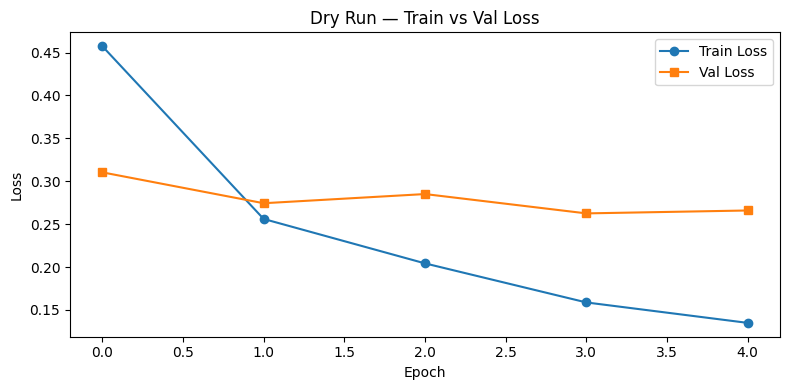

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses,   marker='s', label='Val Loss')
plt.title("Dry Run \u2014 Train vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

The loss curve indicates a consistent reduction in training loss across epochs, confirming that the model is successfully learning meaningful patterns from the data. Although the validation loss exhibits slight fluctuations, it remains relatively stable and does not diverge significantly from the training loss. This behavior suggests that the training process is functioning correctly during the dry run, with no evident signs of severe overfitting.

### Primary metrics

In [22]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
print(f"Validation Accuracy: {acc:.4f} ({acc*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Fake (0)", "Real (1)"]
))

Validation Accuracy: 0.9108 (91.08%)

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.91      0.93      0.92      3479
    Real (1)       0.91      0.89      0.90      2887

    accuracy                           0.91      6366
   macro avg       0.91      0.91      0.91      6366
weighted avg       0.91      0.91      0.91      6366



<Figure size 600x500 with 0 Axes>

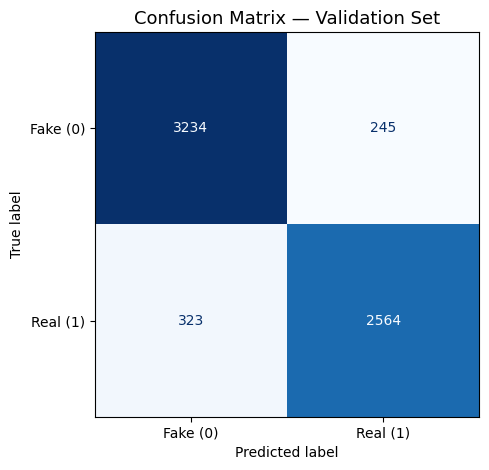

In [23]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Fake (0)", "Real (1)"])
disp.plot(colorbar=False, cmap="Blues")
plt.title("Confusion Matrix \u2014 Validation Set", fontsize=13)
plt.tight_layout()
plt.show()

### Detailed Performance Breakdown

**Label convention:** In this task, **Fake (0) is treated as the positive class**, since the system's objective is *detecting* fake news. Under this convention:

- **False Negative** = a fake article predicted as real (a *missed* fake — the critical error)
- **False Positive** = a real article predicted as fake (a *false alarm*)

Note: `sklearn`'s `cm.ravel()` assumes label 1 is positive, which is the opposite of our convention, so we index the confusion matrix explicitly.

In [24]:
# Positive class = Fake (0): the class the detector is built to find.
# sklearn cm layout (labels [0,1]): rows = true, cols = predicted
#   cm[0,0] Fake->Fake   cm[0,1] Fake->Real
#   cm[1,0] Real->Fake   cm[1,1] Real->Real
tp_fake = cm[0, 0]   # Fake predicted as Fake  -> True Positive
fn_fake = cm[0, 1]   # Fake predicted as Real  -> False Negative (missed fake)
fp_fake = cm[1, 0]   # Real predicted as Fake  -> False Positive (false alarm)
tn_fake = cm[1, 1]   # Real predicted as Real  -> True Negative

print("--- Detailed Performance Breakdown (positive class = Fake) ---")
print(f"True Positives  (Fake predicted as Fake) : {tp_fake}")
print(f"False Negatives (Fake predicted as Real) : {fn_fake}  <- missed fakes")
print(f"False Positives (Real predicted as Fake) : {fp_fake}  <- false alarms")
print(f"True Negatives  (Real predicted as Real) : {tn_fake}")
print(f"\nPrecision (Fake) : {tp_fake / (tp_fake + fp_fake):.4f}")
print(f"Recall    (Fake) : {tp_fake / (tp_fake + fn_fake):.4f}")
print(f"F1-Score  (Fake) : {2*tp_fake / (2*tp_fake + fp_fake + fn_fake):.4f}")

--- Detailed Performance Breakdown (positive class = Fake) ---
True Positives  (Fake predicted as Fake) : 3234
False Negatives (Fake predicted as Real) : 245  <- missed fakes
False Positives (Real predicted as Fake) : 323  <- false alarms
True Negatives  (Real predicted as Real) : 2564

Precision (Fake) : 0.9092
Recall    (Fake) : 0.9296
F1-Score  (Fake) : 0.9193


### Dry Run Analysis

The dry run confirms that:

- The preprocessing pipeline works correctly.
- The forward pass executes without errors.
- The training loop runs end-to-end.
- The loss decreases over epochs, indicating proper gradient flow.
- **All randomness is seeded (`SEED = 42`), so the reported results are fully reproducible.**

This validates the correct implementation of the Transformer encoder components.